In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_format='svg'
from scipy.sparse.linalg import svds

**准备数据**

In [2]:
task3_df=pd.read_csv('task2_df.csv')
task3_df['movie_genre'] = task3_df['movie_genre'].apply(eval)

In [3]:
df=task3_df.copy()
df

,user_id,movie_id,rating,gender,age,occupation,movie_year,movie_genre
0,2,1357,5,M,56,16,96,"[Drama, Romance]"
1,2,3068,4,M,56,16,82,[Drama]
2,2,1537,4,M,56,16,96,[Comedy]
3,2,647,3,M,56,16,96,"[Drama, War]"
4,2,2194,4,M,56,16,87,"[Action, Crime, Drama]"
...,...,...,...,...,...,...,...,...
843697,6040,1091,1,M,25,6,89,[Comedy]
843698,6040,1094,5,M,25,6,92,"[Drama, Romance, War]"
843699,6040,562,5,M,25,6,95,"[Comedy, Drama]"
843700,6040,1096,4,M,25,6,82,[Drama]


**下面实现基于SVD的协同过滤**；有了相似度之后，实际上用户代表电影的选取工作都可以从这里出发。

评分矩阵生成，由于用户数目少于电影数目，采取基于电影的协同过滤

In [4]:
ratings_matrix = pd.pivot_table(df, values='rating', index='user_id', columns='movie_id', fill_value=0)

In [5]:
ratings_matrix

movie_id,1,2,3,4,5,6,7,8,9,10,...,3943,3944,3945,3946,3947,3948,3949,3950,3951,3952
user_id,,,,,,,,,,,,,,,,,,,,,
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,4,0,0,3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,3,0,0,0,0
10,5,5,0,0,0,0,4,0,0,0,...,0,0,0,0,0,4,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6035,4,0,1,2,1,0,3,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6036,0,0,0,2,0,3,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6037,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
ratings_matrix.iloc[33,10]

0

In [7]:
matrix_t=ratings_matrix.T.values
matrix_t=matrix_t.astype(float)
##有一小部分电影，这些用户都没评分，所以列数小于3952，剩下的电影参考价值很小，故不考虑。

In [8]:
matrix_t.shape

(3670, 2909)

奇异值分解

In [9]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse.linalg import svds
from sklearn.metrics.pairwise import pairwise_distances

U, sigma, Vt = svds(matrix_t, k = 20)
sigma = np.diag(sigma)
all_movie_predicted_ratings = np.dot(np.dot(U, sigma), Vt)

In [10]:
all_movie_predicted_ratings_mean = np.mean(all_movie_predicted_ratings, axis=0)
all_movie_predicted_ratings_normalized = all_movie_predicted_ratings - all_movie_predicted_ratings_mean

# 计算每对电影之间的余弦相似度
movie_similarity = 1 - pairwise_distances(all_movie_predicted_ratings_normalized, metric='cosine')
movie_similarity.shape

(3670, 3670)

有了协同过滤算法得出的余弦相似度，事实上，可以这样得出每个用户的推荐/表征电影：

每个用户打5分的电影中，被同龄人观看次数最多的电影取前5名--和这5个电影最相似（依据相似度矩阵），且这个用户没看过的5个电影。

In [11]:
user_set=set(df.user_id)

In [12]:
df_users=df.groupby('user_id')

In [13]:
df_ex=task3_df.explode('movie_genre')
df_ex

,user_id,movie_id,rating,gender,age,occupation,movie_year,movie_genre
0,2,1357,5,M,56,16,96,Drama
0,2,1357,5,M,56,16,96,Romance
1,2,3068,4,M,56,16,82,Drama
2,2,1537,4,M,56,16,96,Comedy
3,2,647,3,M,56,16,96,Drama
...,...,...,...,...,...,...,...,...
843700,6040,1096,4,M,25,6,82,Drama
843701,6040,1097,4,M,25,6,82,Children's
843701,6040,1097,4,M,25,6,82,Drama
843701,6040,1097,4,M,25,6,82,Fantasy


In [14]:
ex_grouped=df_ex.groupby(['user_id','movie_genre']).agg({'rating':'mean','movie_id':'count'}).reset_index()

In [15]:
ex_grouped

,user_id,movie_genre,rating,movie_id
0,2,Action,3.500000,56
1,2,Adventure,3.736842,19
2,2,Comedy,3.560000,25
3,2,Crime,3.583333,12
4,2,Drama,3.898734,79
...,...,...,...,...
49899,6040,Romance,3.488889,45
49900,6040,Sci-Fi,3.473684,38
49901,6040,Thriller,3.926829,41
49902,6040,War,3.695652,23


In [16]:
ex_grouped['score'] = ex_grouped['rating'] * 10 * ex_grouped['movie_id']
sort = (ex_grouped.groupby(['user_id', 'movie_genre'])
               .apply(lambda x: x.sort_values('score', ascending=False))
               .reset_index(drop=True))

获取最喜欢或者最不喜欢的电影，把打分按照从高到低排序即可，结果在下面的sorted_df中

In [17]:
sorted_df = sort.groupby('user_id').apply(lambda x : x.sort_values(by= 'score', ascending=False))
sorted_df = sorted_df[['user_id', 'movie_genre', 'score']]
sorted_df

user_id movie_genre   score
user_id                                   
2       4            2       Drama  3080.0
        0            2      Action  1960.0
        11           2    Thriller  1080.0
        2            2      Comedy   890.0
        9            2     Romance   890.0
...                ...         ...     ...
6040    49897     6040     Musical   360.0
        49889     6040  Children's   240.0
        49894     6040     Fantasy   210.0
        49888     6040   Animation   120.0
        49903     6040     Western    80.0

[49904 rows x 3 columns]

In [18]:
user_genre_counts = df_ex.groupby(['user_id', 'movie_genre']).size().reset_index(name='count')
user_top_genres = user_genre_counts.groupby('user_id').apply(lambda x: x.nlargest(5, 'count')).reset_index(drop=True)

In [19]:
user_top_genres

,user_id,movie_genre,count
0,2,Drama,79
1,2,Action,56
2,2,Thriller,31
3,2,Comedy,25
4,2,Romance,24
...,...,...,...
14540,6040,Drama,185
14541,6040,Comedy,102
14542,6040,Romance,45
14543,6040,Action,42


**下面进行特定小标签（小群体）的标注工作示例**

准备数据：

In [20]:
df

,user_id,movie_id,rating,gender,age,occupation,movie_year,movie_genre
0,2,1357,5,M,56,16,96,"[Drama, Romance]"
1,2,3068,4,M,56,16,82,[Drama]
2,2,1537,4,M,56,16,96,[Comedy]
3,2,647,3,M,56,16,96,"[Drama, War]"
4,2,2194,4,M,56,16,87,"[Action, Crime, Drama]"
...,...,...,...,...,...,...,...,...
843697,6040,1091,1,M,25,6,89,[Comedy]
843698,6040,1094,5,M,25,6,92,"[Drama, Romance, War]"
843699,6040,562,5,M,25,6,95,"[Comedy, Drama]"
843700,6040,1096,4,M,25,6,82,[Drama]


In [21]:
ratings=pd.read_csv('ratings2.csv')
popular=ratings.groupby('movie_id')['rating'].count()
ratings

,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291
...,...,...,...,...
1000204,6040,1091,1,956716541
1000205,6040,1094,5,956704887
1000206,6040,562,5,956704746
1000207,6040,1096,4,956715648


In [22]:
movies=pd.read_csv('movies.csv')
movies

,Unnamed: 0,movie_id,title,genres
0,0,1,Toy Story (1995),Animation|Children's|Comedy
1,1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,2,3,Grumpier Old Men (1995),Comedy|Romance
3,3,4,Waiting to Exhale (1995),Comedy|Drama
4,4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...,...
3878,3878,3948,Meet the Parents (2000),Comedy
3879,3879,3949,Requiem for a Dream (2000),Drama
3880,3880,3950,Tigerland (2000),Drama
3881,3881,3951,Two Family House (2000),Drama


定义‘争议之作’：1分和5分比例都大于10%,比较流行的

In [23]:
counts = df.groupby(['movie_id']).agg({'rating':lambda x:sum((x<2))/len(x)}).reset_index()

In [24]:
counts['good_rate']=df.groupby(['movie_id']).agg({'rating':lambda x:sum((x>4))/len(x)})
counts.columns=['movie_id','bad_rate','good_rate']

In [25]:
diverged=[]
def find(x):
    if (x['bad_rate']>=0.1) & (x['good_rate']>=0.1)& (popular[x.movie_id]>=300):
        diverged.append(int(x.movie_id))
div_return=counts.apply(find,axis=1)
#diverged是一个列表，里面是争议之作的id

In [26]:
rates=df.groupby('movie_id')['rating'].mean()

定义“怀旧经典”：观看的人当中年龄56以上的比例达到15%，且均分在3.5分以上的

In [27]:
ages=pd.DataFrame(df.groupby(['movie_id'])['age'].value_counts())

In [28]:
total_views = ages['age'].sum(level='movie_id')
age_56 = ages.loc[(slice(None), 56), :]
prop_56 = age_56['age'] / total_views

oldpeople=[]
for i in list(prop_56[prop_56 > 0.15].index.get_level_values('movie_id').unique()):
    if (rates[i]>=3.5):
        oldpeople.append(i)
##结果在odlpeople中，是一个列表

定义“新潮科幻”：类型是Sci-Fi,观看的人当中年龄18和25比例超过20%，比较流行，且均分在3.5分以上的

In [29]:
sci_fi_movies = df[df['movie_genre'].apply(lambda x: 'Sci-Fi' in x)]
scifi_ids = sci_fi_movies['movie_id'].tolist()

total_views = ages['age'].sum(level='movie_id')
age_25 = ages.loc[(slice(None), 25), :]
prop_25 = age_25['age']/ total_views
age_18 = ages.loc[(slice(None), 18), :]
prop_18 = age_18['age']/ total_views

In [30]:
scifi=[]
for i in list(prop_25[prop_25 > 0.2].index.get_level_values('movie_id').unique()):
    if (rates[i]>=3.5) & (popular[i]>=300):
        scifi.append(i)
for i in list(prop_18[prop_18 > 0.2].index.get_level_values('movie_id').unique()):
    if (rates[i]>=3.5) & (popular[i]>=300):
        scifi.append(i)
scifi=list(set(scifi).intersection(set(scifi_ids)))

定义'浪漫爱情”：类型是romance，观看的人当中女性比例超过50\%的

In [31]:
rom_movies = df[df['movie_genre'].apply(lambda x: 'Romance' in x)]
rom_ids =rom_movies['movie_id'].tolist()

In [32]:
gender=df.groupby(['movie_id','gender'])['gender'].count()
df_gender = df.groupby(['movie_id', 'gender'])['gender'].count()
df_gender_pct = df_gender.groupby(level=0).apply(lambda x: x / float(x.sum()))
f_pct = df_gender_pct.loc[:, 'F'].reset_index()
f_pct.columns = ['movie_id', 'F_percent']
females=set(f_pct[f_pct.F_percent>0.5].movie_id)
females=list(females.intersection(set(rom_ids)))

有四个列表，分别叫做diverged,oldpeople,scifi,females。对应我们对电影的标注

对每个用户，统计他们看过这四类电影的频次，可以得到对用户的标注

In [33]:
print(len(diverged),len(scifi),len(females),len(oldpeople))

65 58 60 53


In [34]:
prompting=df.iloc[:,0:2]

下面是对评分列表进行用户的标注

In [35]:
user_diverged_count = prompting[prompting['movie_id'].isin(diverged)].groupby('user_id').size()
result_div = user_diverged_count[user_diverged_count > 30].index.tolist()

In [36]:
user_oldpeople_count = prompting[prompting['movie_id'].isin(oldpeople)].groupby('user_id').size()
result_old = user_oldpeople_count[user_oldpeople_count > 8].index.tolist()

In [37]:
user_scifi_count = prompting[prompting['movie_id'].isin(scifi)].groupby('user_id').size()
result_scifi = user_scifi_count[user_scifi_count > 45].index.tolist()

In [38]:
user_females_count = prompting[prompting['movie_id'].isin(females)].groupby('user_id').size()
result_female = user_females_count[user_females_count > 10].index.tolist()

In [39]:
print(len(result_div),len(result_scifi),len(result_female),len(result_old))

148 122 108 45


In [40]:
len(set(result_scifi).intersection(set(result_female)))

5

In [41]:
len(set(result_old).intersection(set(result_female)))

7

In [42]:
len(set(result_old).intersection(set(result_scifi)))

7

标注的输出都是列表形式，包含一系列id。从两个取交集的结果可以看出，在100多个标注中只有5个取到了爱看科幻片和爱看文艺爱情片的交集，这样的结果是令人满意的。在我们**设置了很高的要求（“提纯”）** 的情况下，总的被标注的用户数量大概占到了用户总数的十分之一；

如果增加标签数量，比如说加入职业，加入看其他类型片（比如战争片）的考量，是能够实现对绝大部分用户的有效标注的。

**下面对电影发烧友们重点分析，绘制雷达图**

In [43]:
big_fans=task3_df.groupby('user_id')['rating'].count()

In [44]:
big_fans=big_fans.sort_values(ascending=False)[0:9]
big_fans

user_id
4169    2314
1680    1850
4277    1743
1941    1595
1181    1521
889     1518
3618    1344
2063    1323
1150    1302
Name: rating, dtype: int64

In [45]:
ex_df_fans=df_ex[df_ex['user_id'].isin(big_fans.index)]
ex_df_fans

,user_id,movie_id,rating,gender,age,occupation,movie_year,movie_genre
113118,889,3789,3,M,45,20,65,Drama
113119,889,2987,4,M,45,20,88,Adventure
113119,889,2987,4,M,45,20,88,Animation
113119,889,2987,4,M,45,20,88,Film-Noir
113120,889,1248,4,M,45,20,58,Crime
...,...,...,...,...,...,...,...,...
601798,4277,2046,4,M,35,16,86,Adventure
601798,4277,2046,4,M,35,16,86,Children's
601798,4277,2046,4,M,35,16,86,Sci-Fi
601799,4277,3788,3,M,35,16,66,Drama


In [46]:
radar=pd.DataFrame(ex_df_fans.groupby(['user_id','movie_genre'])['movie_genre'].count())

In [47]:
radar.columns=['count']

In [48]:
radar=radar.reset_index()

In [49]:
radar_norm=df_ex.groupby("movie_genre")['rating'].count()

In [50]:
radar

,user_id,movie_genre,count
0,889,Action,194
1,889,Adventure,110
2,889,Animation,35
3,889,Children's,54
4,889,Comedy,533
...,...,...,...
157,4277,Romance,168
158,4277,Sci-Fi,208
159,4277,Thriller,378
160,4277,War,93


In [51]:
genre_order = ["War", "Sci-Fi", "Children\'s", "Fantasy", "Romance", "Musical", "Thriller", "Western"]

results = {}
for name, group in radar.groupby('user_id'):
    counts = []
    for genre in genre_order:
        count = group[group['movie_genre'] == genre]['count'].sum()*1000/radar_norm[genre]
        counts.append(count)
    results[name] = counts

在这里，雷达图只注重看倾向就可以，上面的数字没有实用意义

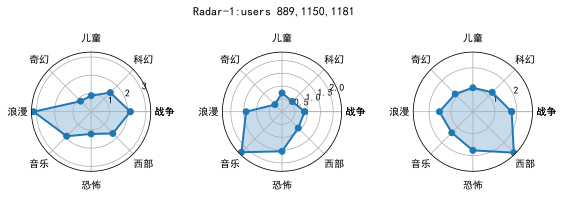

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family']='SimHei'   
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
data=[]
for key in results:
    data.append(results[key])
data=np.array(data)
data=np.clip(data,0,4)

labels = np.array(["战争", "科幻", "儿童", "奇幻", "浪漫","音乐","恐怖","西部"])
dataLenth = 8
data1 = data[0]
data2 = data[1]
data3 = data[2]

angles = np.linspace(0, 2*np.pi, dataLenth, endpoint=False)

# 闭合数据
data1 = np.concatenate((data1, [data1[0]]))
data2 = np.concatenate((data2, [data2[0]]))
data3 = np.concatenate((data3, [data3[0]]))
angles = np.concatenate((angles, [angles[0]]))
labels = np.concatenate((labels, [labels[0]]))

# 创建子图，将三个雷达图拼在一起
fig, axs = plt.subplots(1, 3, figsize=(9, 3), subplot_kw=dict(polar=True))
for ax, data in zip(axs.flat, [data1, data2, data3]):
    ax.plot(angles, data, 'o-', linewidth=2)
    ax.fill(angles, data, alpha=0.25)
    ax.set_thetagrids(angles*180/np.pi, labels)
    ax.set_rlabel_position(180/dataLenth)

# 标题和网格
fig.suptitle('Radar-1:users 889,1150,1181', fontsize=12)
for ax in axs.flat:
    ax.grid(True)
fig.subplots_adjust(wspace=0.6)
plt.savefig('radar1.png')

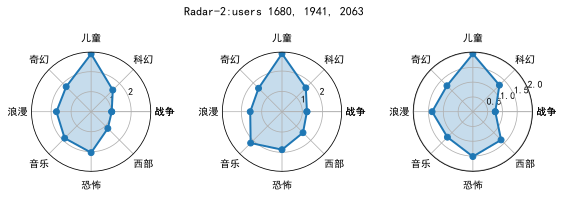

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family']='SimHei'     
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
data=[]
for key in results:
    data.append(results[key])
data=np.array(data)
data=np.clip(data,0,5)

labels = np.array(["战争", "科幻", "儿童", "奇幻", "浪漫","音乐","恐怖","西部"])
dataLenth = 8
data1 = data[3]
data2 = data[4]
data3 = data[5]

angles = np.linspace(0, 2*np.pi, dataLenth, endpoint=False)

# 闭合数据
data1 = np.concatenate((data1, [data1[0]]))
data2 = np.concatenate((data2, [data2[0]]))
data3 = np.concatenate((data3, [data3[0]]))
angles = np.concatenate((angles, [angles[0]]))
labels = np.concatenate((labels, [labels[0]]))

# 创建子图，将三个雷达图拼在一起
fig, axs = plt.subplots(1, 3, figsize=(9, 3), subplot_kw=dict(polar=True))
for ax, data in zip(axs.flat, [data1, data2, data3]):
    ax.plot(angles, data, 'o-', linewidth=2)
    ax.fill(angles, data, alpha=0.25)
    ax.set_thetagrids(angles*180/np.pi, labels)
    ax.set_rlabel_position(180/dataLenth)

# 标题和网格
fig.suptitle('Radar-2:users 1680, 1941, 2063', fontsize=12)
for ax in axs.flat:
    ax.grid(True)
fig.subplots_adjust(wspace=0.6)
plt.savefig('radar2.png')

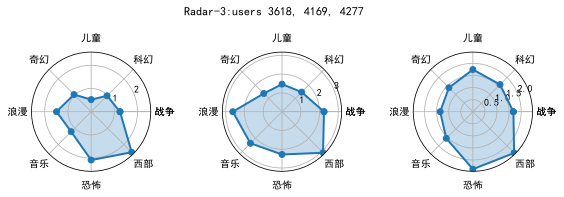

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family']='SimHei'     #将字体设置为黑体'SimHei'
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
data=[]
for key in results:
    data.append(results[key])
data=np.array(data)
data=np.clip(data,0,5)

labels = np.array(["战争", "科幻", "儿童", "奇幻", "浪漫","音乐","恐怖","西部"])
dataLenth = 8
data1 = data[6]
data2 = data[7]
data3 = data[8]

angles = np.linspace(0, 2*np.pi, dataLenth, endpoint=False)

# 闭合数据
data1 = np.concatenate((data1, [data1[0]]))
data2 = np.concatenate((data2, [data2[0]]))
data3 = np.concatenate((data3, [data3[0]]))
angles = np.concatenate((angles, [angles[0]]))
labels = np.concatenate((labels, [labels[0]]))

# 创建子图，将三个雷达图拼在一起
fig, axs = plt.subplots(1, 3, figsize=(9, 3), subplot_kw=dict(polar=True))
for ax, data in zip(axs.flat, [data1, data2, data3]):
    ax.plot(angles, data, 'o-', linewidth=2)
    ax.fill(angles, data, alpha=0.25)
    ax.set_thetagrids(angles*180/np.pi, labels)
    ax.set_rlabel_position(180/dataLenth)

# 添加标题和网格
fig.suptitle('Radar-3:users 3618, 4169, 4277', fontsize=12)
for ax in axs.flat:
    ax.grid(True)
fig.subplots_adjust(wspace=0.6)
plt.savefig('radar3.png')

In [55]:
user=pd.read_csv('users.csv')

In [56]:
inf = user.loc[user['user_id'].isin(big_fans.index)]

In [57]:
inf

,Unnamed: 0,user_id,gender,age,occupation,zipcode,age_desc,occ_desc
888,888,889,M,45,20,10024,45-49,writer
1149,1149,1150,F,25,20,75226,25-34,writer
1180,1180,1181,M,35,7,20716,35-44,executive/managerial
1679,1679,1680,M,25,20,95380,25-34,writer
1940,1940,1941,M,35,17,94550,35-44,technician/engineer
2062,2062,2063,M,25,4,43138,25-34,college/grad student
3617,3617,3618,M,56,17,22657,56+,technician/engineer
4168,4168,4169,M,50,0,66048,50-55,other or not specified
4276,4276,4277,M,35,16,98133,35-44,self-employed
